In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parametros de conexion
db_host = 'localhost'
db_port = '5432'
db_name = 'mp3_database'
db_user = 'postgres'
db_pass = 'postgres'

# Crear el engine (conexion sql)
engine = create_engine(f'postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}')

                        nombre  total_vendido
0                AUDIFONO PROX              7
1                   MP3PREMIUM              6
2                    CARGADORN              4
3          MOCHILA PARA CAMARA              2
4    AURICULARES BLUETOOTH JBL              2
5        CARGADOR RAPIDO QC3.0              2
6       PARLANTE PORTATIL BOSE              2
7  BICICLETA ELECTRICA ECOBIKE              2
8             MOCHILA ULTRAPRO              2
9   CARGADOR SOLAR POWERCHARGE              2


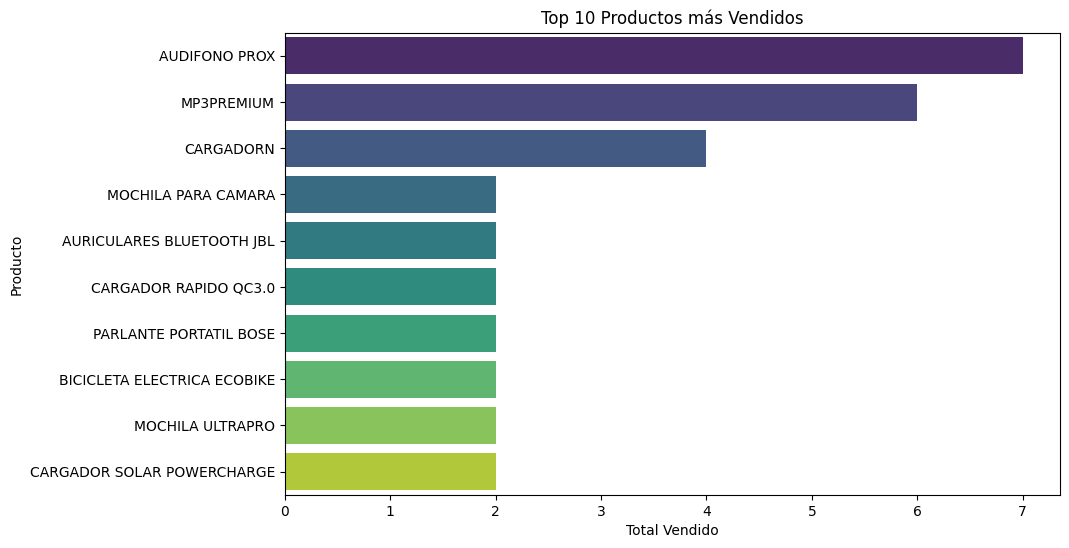

In [2]:
# Top 10 productos mas vendidos, realizamos un join con la tabla de productos para obtener, de las ventas realizadas cual fue el producto con mas ventas
# y los 9 siguientes top 10 o limit 10 ordenado por total vendido de manera descendente 
top_10_productos = pd.read_sql("""
SELECT dp.nombre, 
       SUM(hv.cantidad) AS total_vendido
FROM hechos_ventas hv
JOIN dim_producto dp ON hv.id_producto = dp.id_producto
GROUP BY dp.nombre
ORDER BY total_vendido DESC
LIMIT 10;
""", engine)
print(top_10_productos)

# grafico sencillo 
plt.figure(figsize=(10, 6))
sns.barplot(x='total_vendido', y='nombre', data=top_10_productos, hue='nombre', palette='viridis', legend=False)
plt.title('Top 10 Productos más Vendidos')
plt.xlabel('Total Vendido')
plt.ylabel('Producto')
plt.show()

            nombre  num_pedidos
0      ELENA LOPEZ            4
1  CARLOS GONZALEZ            1
2  CAROLINA TORRES            1
3     CLAUDIA DIAZ            1
4  ANTONIO SANCHEZ            1


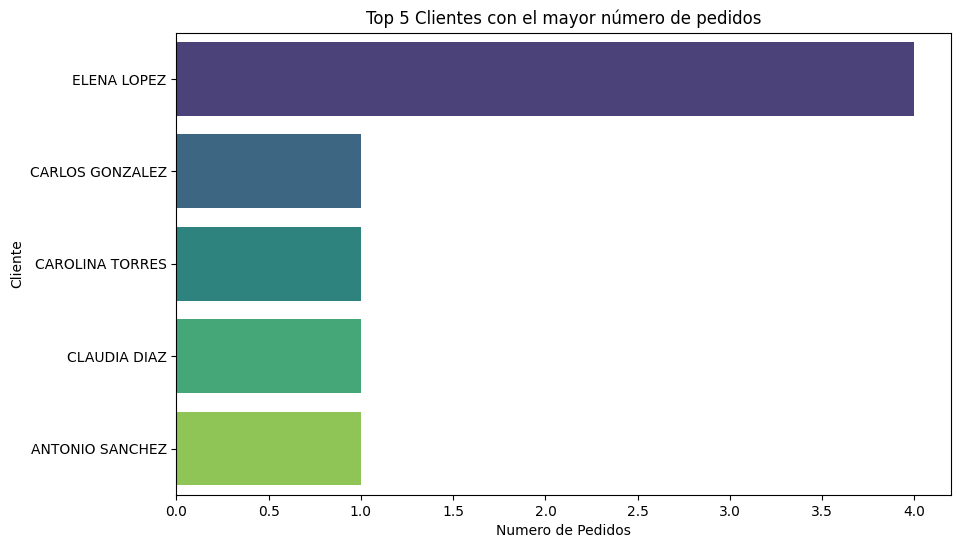

In [3]:
# Top 5 Clientes con el mayor número de pedidos, en este caso realizamos un join con clientes para saber el numero de pedidos realizados por cada cliente, se realizo una concatenacion del id del producto con la fecha para saber distintamente cuantos perdidos a realziado el cliente

top_5_clientes = pd.read_sql("""
SELECT dc.nombre, 
       COUNT(distinct concat(hv.id_fecha, hv.id_producto)) AS num_pedidos
FROM hechos_ventas hv
JOIN dim_cliente dc ON hv.id_cliente = dc.id_cliente
GROUP BY dc.nombre
ORDER BY num_pedidos DESC
LIMIT 5;
""", engine)
print(top_5_clientes)

plt.figure(figsize=(10, 6))
sns.barplot(x='num_pedidos', y='nombre', data=top_5_clientes, hue='nombre', palette='viridis', legend=False)
plt.title('Top 5 Clientes con el mayor número de pedidos')
plt.xlabel('Numero de Pedidos')
plt.ylabel('Cliente')
plt.show()


           nombre  num_pedidos
0   PAGAEXPRESS 3            4
1         GIROSYA            1
2     PAGAEXPRESS            1
3   PAGAEXPRESS 2            1
4  GIROSEXPRESS 2            1


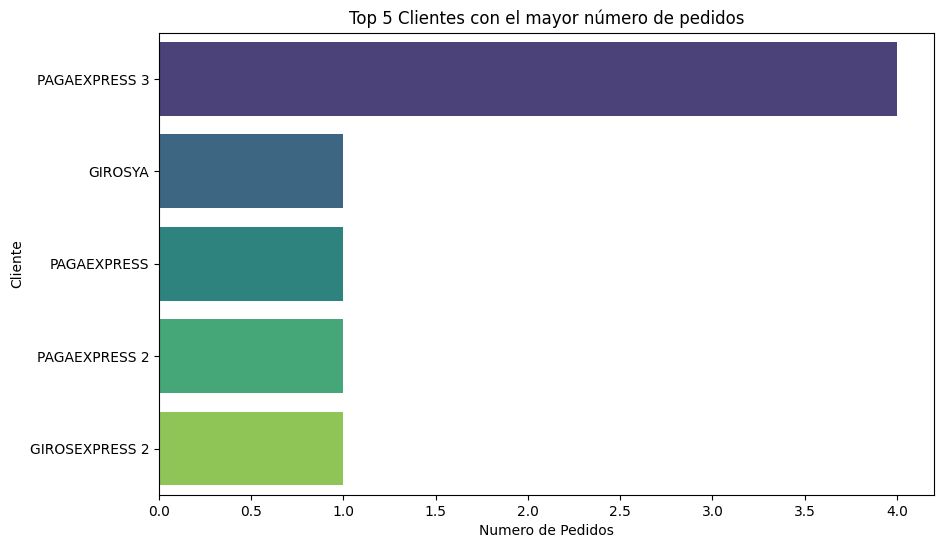

In [4]:
# Top 5 Corresponsales con el mayor número de pedidos se realizo basicamente lo mismo que el reporte anterior cambiando los clientes por corresponsales

top_5_corresponsales = pd.read_sql("""
SELECT dc.nombre, 
       COUNT(distinct concat(hv.id_fecha, hv.id_producto)) AS num_pedidos
FROM hechos_ventas hv
JOIN dim_corresponsal dc ON hv.id_corresponsal = dc.id_corresponsal
GROUP BY dc.nombre
ORDER BY num_pedidos DESC
LIMIT 5;
""", engine)
print(top_5_corresponsales)

plt.figure(figsize=(10, 6))
sns.barplot(x='num_pedidos', y='nombre', data=top_5_corresponsales, hue='nombre', palette='viridis', legend=False)
plt.title('Top 5 Clientes con el mayor número de pedidos')
plt.xlabel('Numero de Pedidos')
plt.ylabel('Cliente')
plt.show()


     mes                       nombre  total_pago
0    4.0                AUDIFONO PROX     1121.91
1    4.0                   MP3PREMIUM      874.99
2    4.0           CARGADOR USBC DUAL      874.99
3    4.0          TECLADO MECANICO GX      421.01
4    8.0             MOCHILA ULTRAPRO      319.99
5    1.0      CAMARA DIGITAL SMARTCAM      249.99
6   10.0     BOCINA BLUETOOTH BASSMAX      200.00
7   11.0    AURICULARES BLUETOOTH JBL      179.99
8    6.0                    CARGADORN      174.00
9    3.0          SMARTWATCH FITTRACK      170.00
10   9.0          MOUSE GAMING XTREME      160.00
11   2.0   CARGADOR SOLAR POWERCHARGE      159.99
12   1.0     PANTALLA LED 32" FULL HD      150.00
13   7.0       PARLANTE PORTATIL BOSE      139.99
14   5.0                   MP3PREMIUM      132.13
15   6.0       DISCO DURO EXTERNO 1TB      130.00
16   6.0        CARGADOR RAPIDO QC3.0      119.99
17   9.0           RATON OPTICO XTECH      110.00
18   8.0          MOCHILA PARA CAMARA       99.99


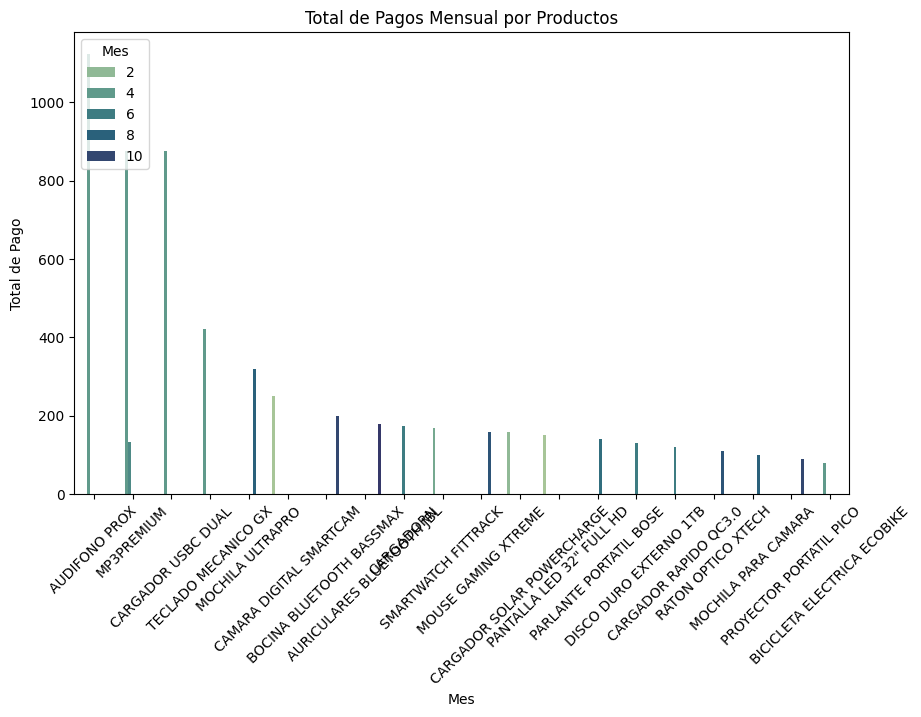

In [5]:
# Total de pagos mensual por productos
pagos_mensuales = pd.read_sql("""
SELECT EXTRACT(MONTH FROM hv.id_fecha) AS mes
,dp.nombre,
SUM(hv.total) AS total_pago       
FROM hechos_ventas hv
JOIN dim_producto dp ON hv.id_producto = dp.id_producto
GROUP BY EXTRACT(MONTH FROM hv.id_fecha),dp.nombre
ORDER BY total_pago DESC;
""", engine)
print(pagos_mensuales)

plt.figure(figsize=(10, 6))
sns.barplot(x='nombre', y='total_pago', data=pagos_mensuales, hue='mes', palette='crest')
plt.title('Total de Pagos Mensual por Productos')
plt.xlabel('Mes')
plt.ylabel('Total de Pago')
plt.xticks(rotation=45)
plt.legend(title="Mes", loc="upper left")
plt.show()



     dia                       nombre  total_pago
0   20.0                   MP3PREMIUM      874.99
1   20.0                AUDIFONO PROX      874.99
2   20.0           CARGADOR USBC DUAL      874.99
3    4.0          TECLADO MECANICO GX      421.01
4    5.0             MOCHILA ULTRAPRO      319.99
5    1.0      CAMARA DIGITAL SMARTCAM      249.99
6    1.0                AUDIFONO PROX      246.92
7    8.0     BOCINA BLUETOOTH BASSMAX      200.00
8    9.0    AURICULARES BLUETOOTH JBL      179.99
9    1.0                    CARGADORN      174.00
10  10.0          SMARTWATCH FITTRACK      170.00
11   6.0          MOUSE GAMING XTREME      160.00
12  11.0   CARGADOR SOLAR POWERCHARGE      159.99
13  11.0     PANTALLA LED 32" FULL HD      150.00
14  13.0       PARLANTE PORTATIL BOSE      139.99
15   2.0                   MP3PREMIUM      132.13
16  14.0       DISCO DURO EXTERNO 1TB      130.00
17  15.0        CARGADOR RAPIDO QC3.0      119.99
18  16.0           RATON OPTICO XTECH      110.00


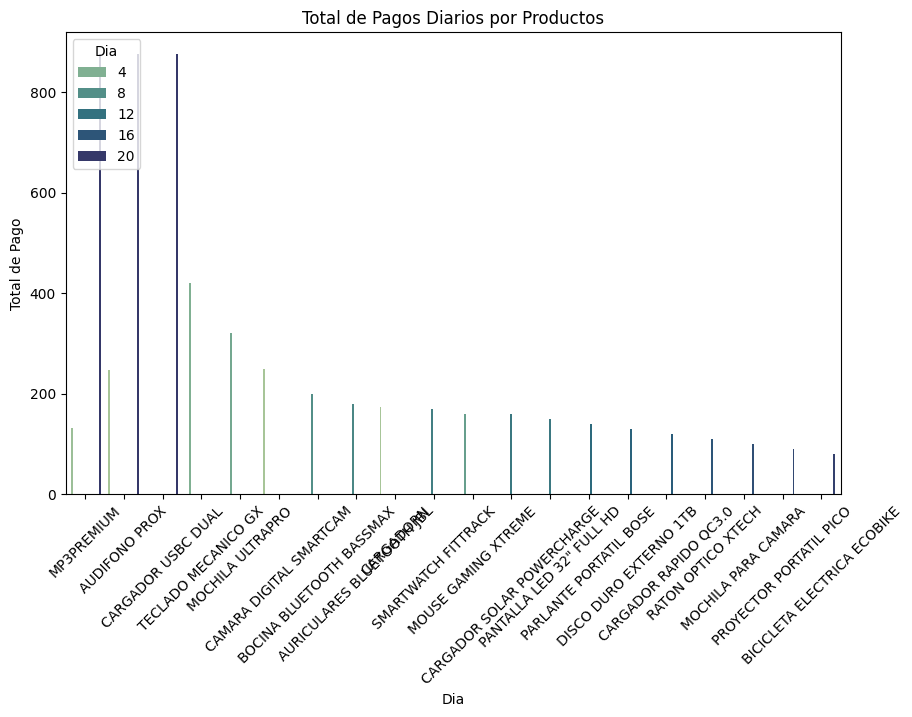

In [6]:
# Total de pagos diario por productos
pagos_diarios = pd.read_sql("""
SELECT EXTRACT(DAY FROM hv.id_fecha) AS dia
,dp.nombre,
SUM(hv.total) AS total_pago       
FROM hechos_ventas hv
JOIN dim_producto dp ON hv.id_producto = dp.id_producto
GROUP BY EXTRACT(DAY FROM hv.id_fecha),dp.nombre
ORDER BY total_pago DESC;
""", engine)
print(pagos_diarios)

plt.figure(figsize=(10, 6))
sns.barplot(x='nombre', y='total_pago', data=pagos_diarios, hue='dia', palette='crest')
plt.title('Total de Pagos Diarios por Productos')
plt.xlabel('Dia')
plt.ylabel('Total de Pago')
plt.xticks(rotation=45)
plt.legend(title="Dia", loc="upper left")
plt.show()



     mes               nombre  total_pago
0    4.0          ELENA LOPEZ     2704.96
1    4.0      CARLOS GONZALEZ      421.01
2    8.0      MARTA RODRIGUEZ      319.99
3    1.0         MARIA GARCIA      249.99
4    4.0           JOSE PEREZ      246.92
5   10.0        ROBERTO LOPEZ      200.00
6   11.0          LAURA PEREZ      179.99
7    6.0           LUISANDRES      174.00
8    3.0       DAVID MARTINEZ      170.00
9    9.0        PEDRO ALVAREZ      160.00
10   2.0         CLAUDIA DIAZ      159.99
11   1.0      ANTONIO SANCHEZ      150.00
12   7.0           JOSE LOPEZ      139.99
13   5.0      ANA MARIA NUNEZ      132.13
14   6.0      CAROLINA TORRES      130.00
15   6.0         LUIS RAMIREZ      119.99
16   9.0     GABRIELA JIMENEZ      110.00
17   8.0  FRANCISCO RODRIGUEZ       99.99
18  10.0       SOFIA MARTINEZ       90.00


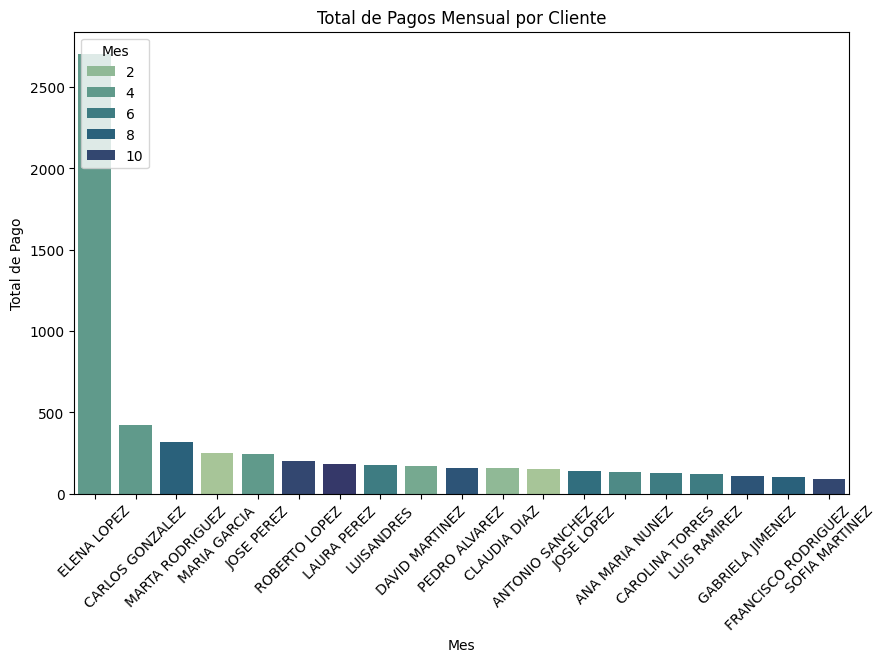

In [7]:
# Total de pagos mensual por clientes
pagos_mensuales_cliente = pd.read_sql("""
SELECT EXTRACT(MONTH FROM hv.id_fecha) AS mes
,dp.nombre,
SUM(hv.total) AS total_pago       
FROM hechos_ventas hv
JOIN dim_cliente dp ON hv.id_cliente = dp.id_cliente
GROUP BY EXTRACT(MONTH FROM hv.id_fecha),dp.nombre
ORDER BY total_pago DESC;
""", engine)
print(pagos_mensuales_cliente)

plt.figure(figsize=(10, 6))
sns.barplot(x='nombre', y='total_pago', data=pagos_mensuales_cliente, hue='mes', palette='crest')
plt.title('Total de Pagos Mensual por Cliente')
plt.xlabel('Mes')
plt.ylabel('Total de Pago')
plt.xticks(rotation=45)
plt.legend(title="Mes", loc="upper left")
plt.show()

     dia               nombre  total_pago
0   20.0          ELENA LOPEZ     2624.97
1    4.0      CARLOS GONZALEZ      421.01
2    5.0      MARTA RODRIGUEZ      319.99
3    1.0         MARIA GARCIA      249.99
4    1.0           JOSE PEREZ      246.92
5    8.0        ROBERTO LOPEZ      200.00
6    9.0          LAURA PEREZ      179.99
7    1.0           LUISANDRES      174.00
8   10.0       DAVID MARTINEZ      170.00
9    6.0        PEDRO ALVAREZ      160.00
10  11.0         CLAUDIA DIAZ      159.99
11  11.0      ANTONIO SANCHEZ      150.00
12  13.0           JOSE LOPEZ      139.99
13   2.0      ANA MARIA NUNEZ      132.13
14  14.0      CAROLINA TORRES      130.00
15  15.0         LUIS RAMIREZ      119.99
16  16.0     GABRIELA JIMENEZ      110.00
17  17.0  FRANCISCO RODRIGUEZ       99.99
18  18.0       SOFIA MARTINEZ       90.00
19  19.0          ELENA LOPEZ       79.99


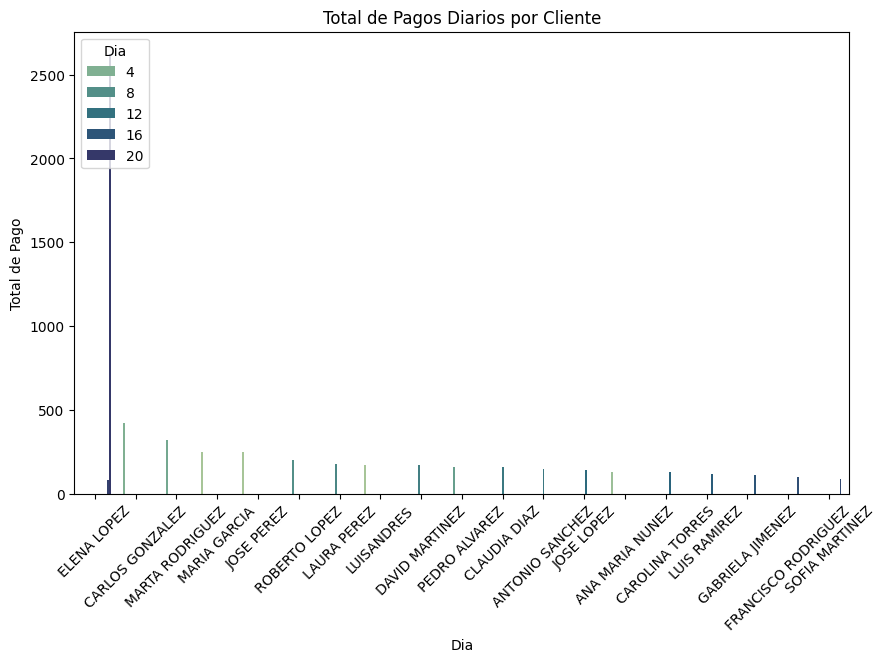

In [8]:
# Total de pagos diario por cliente
pagos_diarios_cliente = pd.read_sql("""
SELECT EXTRACT(DAY FROM hv.id_fecha) AS dia
,dp.nombre,
SUM(hv.total) AS total_pago       
FROM hechos_ventas hv
JOIN dim_cliente dp ON hv.id_cliente = dp.id_cliente
GROUP BY EXTRACT(DAY FROM hv.id_fecha),dp.nombre
ORDER BY total_pago DESC;
""", engine)
print(pagos_diarios_cliente)

plt.figure(figsize=(10, 6))
sns.barplot(x='nombre', y='total_pago', data=pagos_diarios_cliente, hue='dia', palette='crest')
plt.title('Total de Pagos Diarios por Cliente')
plt.xlabel('Dia')
plt.ylabel('Total de Pago')
plt.xticks(rotation=45)
plt.legend(title="Dia", loc="upper left")
plt.show()

     mes            nombre  total_pago
0    4.0     PAGAEXPRESS 3     2704.96
1    4.0   PAGAFACIL NORTE      421.01
2    8.0           GIROSYA      319.99
3    1.0         SERVIGIRO      249.99
4    4.0  PUNTO EXITO  SUR      246.92
5   10.0          RAPIPAGO      200.00
6   11.0       PAGAEXPRESS      179.99
7    6.0          RAPIGIRO      174.00
8    3.0      GIROSEXPRESS      170.00
9    9.0      PUNTO RAPIDO      160.00
10   2.0    PUNTO RAPIDO 2      159.99
11   1.0       SERVIGIRO 2      150.00
12   7.0        RAPIPAGO 2      139.99
13   5.0       SERVIPAGO N      132.13
14   6.0     PAGAEXPRESS 2      130.00
15   6.0    GIROSEXPRESS 2      119.99
16   9.0    PUNTO RAPIDO 3      110.00
17   8.0       SERVIGIRO 3       99.99
18  10.0        RAPIPAGO 3       90.00


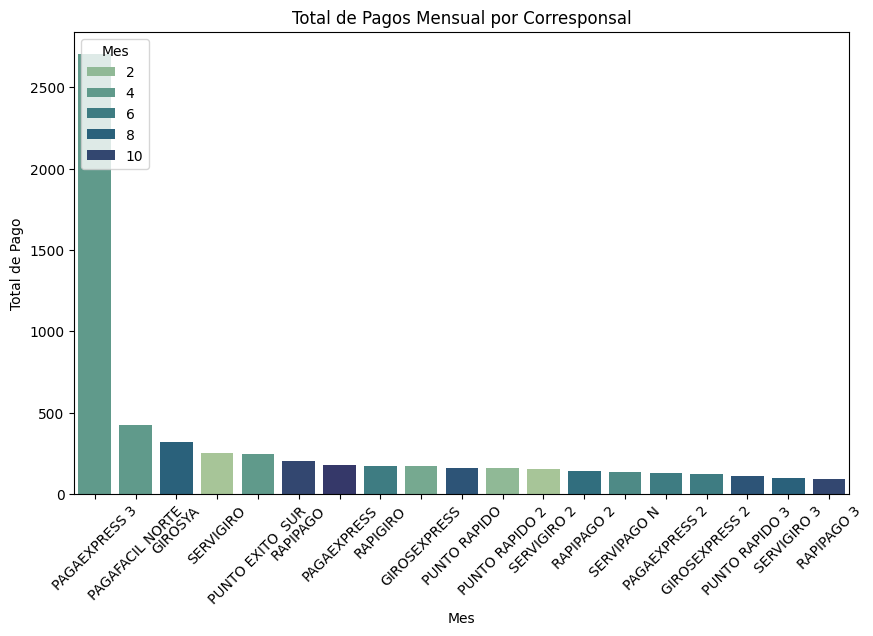

In [9]:
# Total de pagos mensual por corresponsal
pagos_mensuales_corresponsal = pd.read_sql("""
SELECT EXTRACT(MONTH FROM hv.id_fecha) AS mes
,dp.nombre,
SUM(hv.total) AS total_pago       
FROM hechos_ventas hv
JOIN dim_corresponsal dp ON hv.id_corresponsal = dp.id_corresponsal
GROUP BY EXTRACT(MONTH FROM hv.id_fecha),dp.nombre
ORDER BY total_pago DESC;
""", engine)
print(pagos_mensuales_corresponsal)

plt.figure(figsize=(10, 6))
sns.barplot(x='nombre', y='total_pago', data=pagos_mensuales_corresponsal, hue='mes', palette='crest')
plt.title('Total de Pagos Mensual por Corresponsal')
plt.xlabel('Mes')
plt.ylabel('Total de Pago')
plt.xticks(rotation=45)
plt.legend(title="Mes", loc="upper left")
plt.show()

     dia            nombre  total_pago
0   20.0     PAGAEXPRESS 3     2624.97
1    4.0   PAGAFACIL NORTE      421.01
2    5.0           GIROSYA      319.99
3    1.0         SERVIGIRO      249.99
4    1.0  PUNTO EXITO  SUR      246.92
5    8.0          RAPIPAGO      200.00
6    9.0       PAGAEXPRESS      179.99
7    1.0          RAPIGIRO      174.00
8   10.0      GIROSEXPRESS      170.00
9    6.0      PUNTO RAPIDO      160.00
10  11.0    PUNTO RAPIDO 2      159.99
11  11.0       SERVIGIRO 2      150.00
12  13.0        RAPIPAGO 2      139.99
13   2.0       SERVIPAGO N      132.13
14  14.0     PAGAEXPRESS 2      130.00
15  15.0    GIROSEXPRESS 2      119.99
16  16.0    PUNTO RAPIDO 3      110.00
17  17.0       SERVIGIRO 3       99.99
18  18.0        RAPIPAGO 3       90.00
19  19.0     PAGAEXPRESS 3       79.99


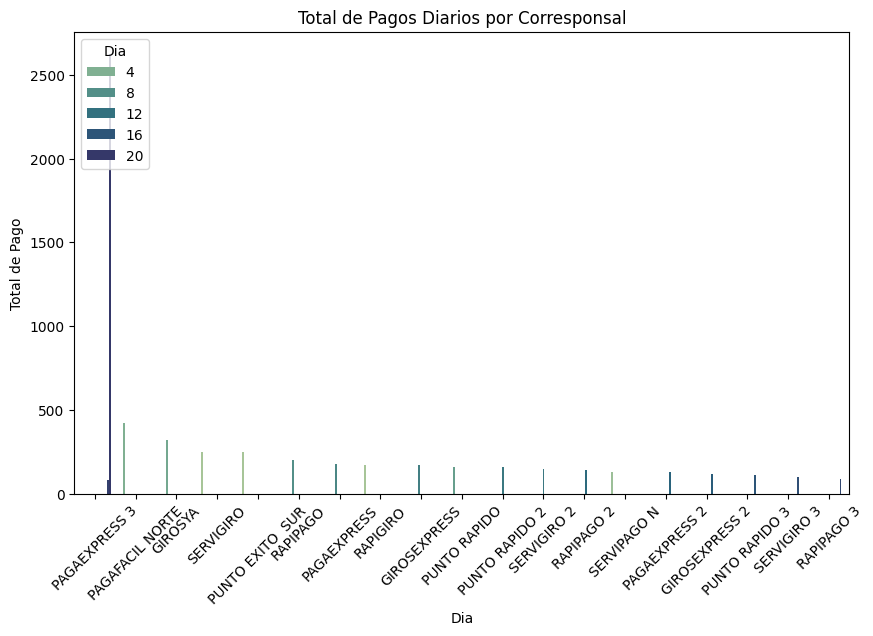

In [10]:
# Total de pagos diario por corresponsal
pagos_diarios_corresponsal = pd.read_sql("""
SELECT EXTRACT(DAY FROM hv.id_fecha) AS dia
,dp.nombre,
SUM(hv.total) AS total_pago       
FROM hechos_ventas hv
JOIN dim_corresponsal dp ON hv.id_corresponsal = dp.id_corresponsal
GROUP BY EXTRACT(DAY FROM hv.id_fecha),dp.nombre
ORDER BY total_pago DESC;
""", engine)
print(pagos_diarios_corresponsal)

plt.figure(figsize=(10, 6))
sns.barplot(x='nombre', y='total_pago', data=pagos_diarios_corresponsal, hue='dia', palette='crest')
plt.title('Total de Pagos Diarios por Corresponsal')
plt.xlabel('Dia')
plt.ylabel('Total de Pago')
plt.xticks(rotation=45)
plt.legend(title="Dia", loc="upper left")
plt.show()

In [11]:
# Variación diaria de pedidos por productos

variacion_productos = pd.read_sql("""SELECT dp.nombre AS producto, 
       hv.id_fecha, 
       SUM(hv.cantidad) AS cantidad_total
FROM hechos_ventas hv
JOIN dim_producto dp ON hv.id_producto = dp.id_producto
GROUP BY dp.nombre, hv.id_fecha
ORDER BY hv.id_fecha, dp.nombre;""", engine)

variacion_productos['variacion'] = variacion_productos.groupby('producto')['cantidad_total'].diff()
print("Variación diaria por producto:")
display(variacion_productos)


Variación diaria por producto:


,producto,id_fecha,cantidad_total,variacion
0,CAMARA DIGITAL SMARTCAM,2024-01-01,2,NaN
1,"PANTALLA LED 32"" FULL HD",2024-01-11,1,NaN
2,CARGADOR SOLAR POWERCHARGE,2024-02-11,2,NaN
3,SMARTWATCH FITTRACK,2024-03-10,1,NaN
4,AUDIFONO PROX,2024-04-01,2,NaN
5,TECLADO MECANICO GX,2024-04-04,2,NaN
6,BICICLETA ELECTRICA ECOBIKE,2024-04-19,2,NaN
7,AUDIFONO PROX,2024-04-20,5,3.0
8,CARGADOR USBC DUAL,2024-04-20,1,NaN
9,MP3PREMIUM,2024-04-20,5,NaN


In [12]:
# Variación diaria de pedidos por corresponsal

variacion_corresponsal = pd.read_sql("""SELECT dp.nombre AS corresponsal, 
       hv.id_fecha, 
       SUM(hv.cantidad) AS cantidad_total
FROM hechos_ventas hv
JOIN dim_corresponsal dp ON hv.id_corresponsal = dp.id_corresponsal
GROUP BY dp.nombre, hv.id_fecha
ORDER BY hv.id_fecha, dp.nombre;""", engine)

variacion_corresponsal['variacion'] = variacion_corresponsal.groupby('corresponsal')['cantidad_total'].diff()
print("Variación diaria por producto:")
display(variacion_corresponsal)

Variación diaria por producto:


,corresponsal,id_fecha,cantidad_total,variacion
0,SERVIGIRO,2024-01-01,2,NaN
1,SERVIGIRO 2,2024-01-11,1,NaN
2,PUNTO RAPIDO 2,2024-02-11,2,NaN
3,GIROSEXPRESS,2024-03-10,1,NaN
4,PUNTO EXITO SUR,2024-04-01,2,NaN
5,PAGAFACIL NORTE,2024-04-04,2,NaN
6,PAGAEXPRESS 3,2024-04-19,2,NaN
7,PAGAEXPRESS 3,2024-04-20,11,9.0
8,SERVIPAGO N,2024-05-02,1,NaN
9,RAPIGIRO,2024-06-01,4,NaN


In [17]:
# Variación diaria de pedidos por productos

variacion_mensual_productos = pd.read_sql("""SELECT dp.nombre AS producto, 
       DATE_TRUNC('month', hv.id_fecha)::date AS mes,
       SUM(hv.cantidad) AS cantidad_total
FROM hechos_ventas hv
JOIN dim_producto dp ON hv.id_producto = dp.id_producto
GROUP BY dp.nombre, DATE_TRUNC('month', hv.id_fecha)
ORDER BY  dp.nombre,mes;""", engine)

variacion_mensual_productos['variacion'] = variacion_mensual_productos.groupby('producto')['cantidad_total'].diff()
print("Variación diaria por producto:")
display(variacion_mensual_productos)

Variación diaria por producto:


,producto,mes,cantidad_total,variacion
0,AUDIFONO PROX,2024-04-01,7,NaN
1,AURICULARES BLUETOOTH JBL,2024-11-01,2,NaN
2,BICICLETA ELECTRICA ECOBIKE,2024-04-01,2,NaN
3,BOCINA BLUETOOTH BASSMAX,2024-10-01,1,NaN
4,CAMARA DIGITAL SMARTCAM,2024-01-01,2,NaN
5,CARGADORN,2024-06-01,4,NaN
6,CARGADOR RAPIDO QC3.0,2024-06-01,2,NaN
7,CARGADOR SOLAR POWERCHARGE,2024-02-01,2,NaN
8,CARGADOR USBC DUAL,2024-04-01,1,NaN
9,DISCO DURO EXTERNO 1TB,2024-06-01,1,NaN


In [ ]:
# Variación Mensual de pedidos por corresponsal, debido a la poca creacion de datos no se denta una variacion en corresponsales mensualmente

variacion_mensual_corresponsales = pd.read_sql("""SELECT 
    dc.nombre AS corresponsal, 
    DATE_TRUNC('month', hv.id_fecha)::date AS mes, 
    SUM(hv.cantidad) AS cantidad_total
FROM hechos_ventas hv
JOIN dim_corresponsal dc ON hv.id_corresponsal = dc.id_corresponsal
GROUP BY dc.nombre, DATE_TRUNC('month', hv.id_fecha)
ORDER BY dc.nombre, mes;""", engine)

variacion_mensual_corresponsales['variacion'] = variacion_mensual_corresponsales.groupby('corresponsal')['cantidad_total'].diff()
print("Variación mensual por corresponsales:")
display(variacion_mensual_corresponsales)

Variación mensual por corresponsales:


,corresponsal,mes,cantidad_total,variacion
0,GIROSEXPRESS,2024-03-01,1,NaN
1,GIROSEXPRESS 2,2024-06-01,2,NaN
2,GIROSYA,2024-08-01,2,NaN
3,PAGAEXPRESS,2024-11-01,2,NaN
4,PAGAEXPRESS 2,2024-06-01,1,NaN
5,PAGAEXPRESS 3,2024-04-01,13,NaN
6,PAGAFACIL NORTE,2024-04-01,2,NaN
7,PUNTO EXITO SUR,2024-04-01,2,NaN
8,PUNTO RAPIDO,2024-09-01,1,NaN
9,PUNTO RAPIDO 2,2024-02-01,2,NaN
